In [ ]:
from google.colab import files

uploaded = files.upload()

Saving images (1).jpg to images (1).jpg


In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
filename = next(iter(uploaded))

image = cv2.imread('/content/' + filename)

image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

print("Image loaded successfully!")

Image loaded successfully!


In [ ]:
h, w = image.shape[:2]

print("Height:", h)
print("Width:", w)

Height: 316
Width: 632


In [ ]:
sx = 2.5
sy = 1.9

scaled = cv2.resize(
    image,
    None,
    fx=sx,
    fy=sy
)

print("Scaling completed!")

Scaling completed!


In [ ]:
h2, w2 = scaled.shape[:2]

center = (w2 // 2, h2 // 2)

angle = 30

M_rotation = cv2.getRotationMatrix2D(
    center,
    angle,
    1.0
)

rotated = cv2.warpAffine(
    scaled,
    M_rotation,
    (w2, h2)
)

print("Rotation completed!")

Rotation completed!


In [ ]:
tx = 80
ty = 63

M_translation = np.float32([
    [1, 0, tx],
    [0, 1, ty]
])

translated = cv2.warpAffine(
    rotated,
    M_translation,
    (w2 + tx, h2 + ty)
)

print("Translation completed!")

Translation completed!


In [ ]:
reflected_x = cv2.flip(translated, 0)

print("X-axis reflection completed!")

X-axis reflection completed!


In [ ]:
reflected_y = cv2.flip(translated, 1)

print("Y-axis reflection completed!")

Y-axis reflection completed!


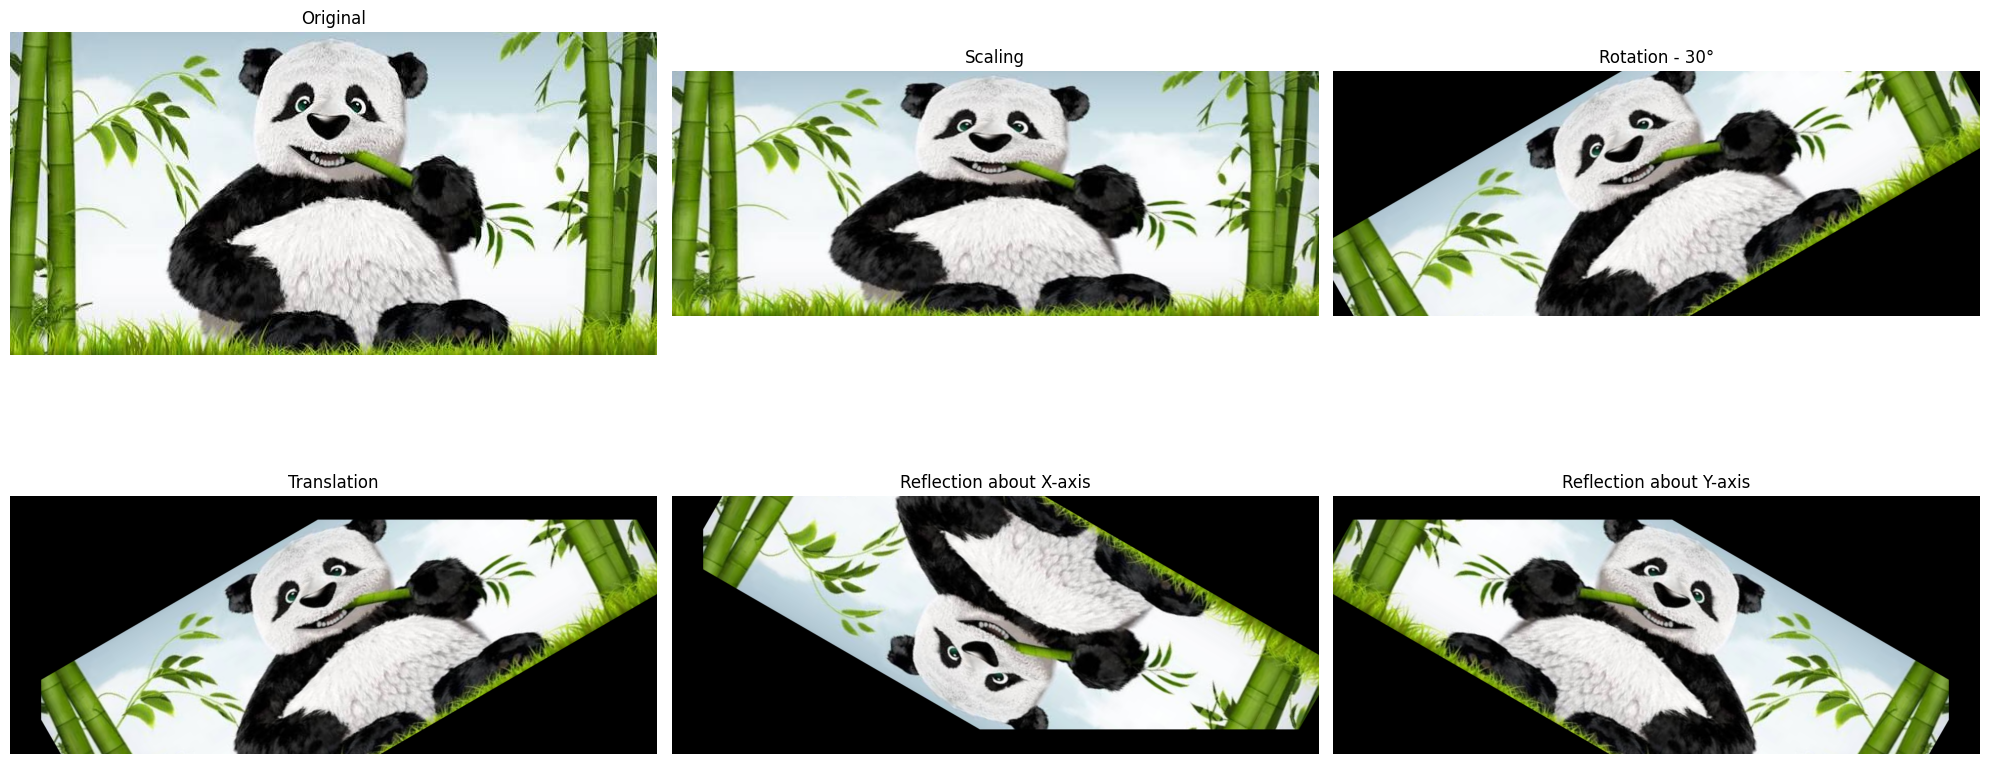

In [ ]:
plt.figure(figsize=(20, 10))

plt.subplot(2, 3, 1)
plt.imshow(image)
plt.title("Original")
plt.axis("off")

plt.subplot(2, 3, 2)
plt.imshow(scaled)
plt.title("Scaling")
plt.axis("off")

plt.subplot(2, 3, 3)
plt.imshow(rotated)
plt.title("Rotation - 30°")
plt.axis("off")

plt.subplot(2, 3, 4)
plt.imshow(translated)
plt.title("Translation")
plt.axis("off")

plt.subplot(2, 3, 5)
plt.imshow(reflected_x)
plt.title("Reflection about X-axis")
plt.axis("off")

plt.subplot(2, 3, 6)
plt.imshow(reflected_y)
plt.title("Reflection about Y-axis")
plt.axis("off")

plt.tight_layout()
plt.show()